## Setup — open the database and load the match table

Run this once. It opens `ipl.db` and adds `matches` to the connection so both tables can be queried with SQL.

In [1]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt

con = sqlite3.connect("ipl.db")                          # the ball-by-ball database
pd.read_csv("tables/matches.csv").to_sql("matches", con, if_exists="replace", index=False)  # add match table

print("tables:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con).name.tolist())

tables: ['deliveries', 'teams', 'players', 'venues', 'matches']


## 1. Chase win rate by first-innings target (H2) — bar
Below 140 the chasing team wins most of the time; at 200+ it wins less than a quarter.

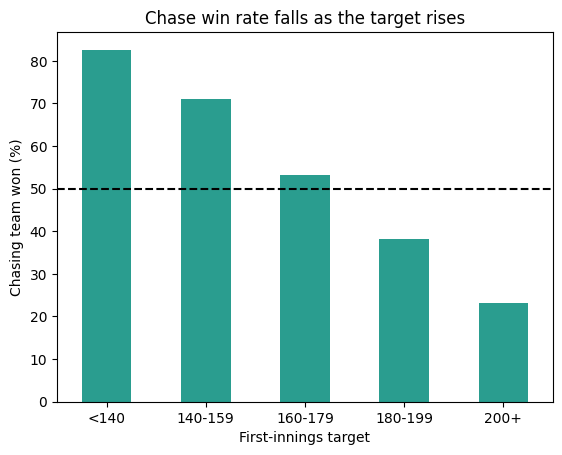

In [2]:
df = pd.read_sql("""
    WITH first_inn AS (SELECT match_id, SUM(total_runs) target
                       FROM deliveries WHERE is_super_over=0 AND innings=1 GROUP BY match_id),
         chaser AS (SELECT match_id, MIN(batting_team) team2
                    FROM deliveries WHERE is_super_over=0 AND innings=2 GROUP BY match_id)
    SELECT CASE WHEN target<140 THEN '<140' WHEN target<160 THEN '140-159'
                WHEN target<180 THEN '160-179' WHEN target<200 THEN '180-199'
                ELSE '200+' END AS target_band,
           ROUND(100.0*AVG(CASE WHEN c.team2=m.match_winner THEN 1 ELSE 0 END),1) AS win_pct
    FROM first_inn f JOIN chaser c USING(match_id) JOIN matches m USING(match_id)
    WHERE m.result='win'
    GROUP BY target_band ORDER BY MIN(target)
""", con, index_col="target_band")
df.plot(kind="bar", rot=0, legend=False, color="#2a9d8f",
        title="Chase win rate falls as the target rises",
        xlabel="First-innings target", ylabel="Chasing team won (%)")
plt.axhline(50, ls="--", c="k"); plt.show()

## 2. Runs per over by phase (C1) — bar
Scoring is fastest at the death (overs 16-20).

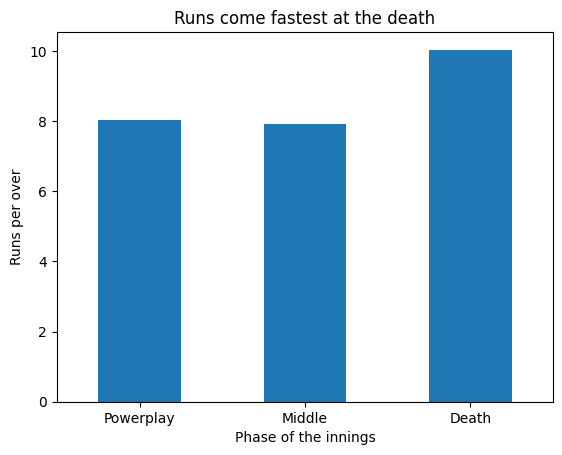

In [3]:
df = pd.read_sql("""
    SELECT CASE WHEN over_number<=5 THEN 'Powerplay'
                WHEN over_number<=14 THEN 'Middle' ELSE 'Death' END AS phase,
           SUM(total_runs)*6.0 / SUM(CASE WHEN is_wide_ball=0 AND is_no_ball=0 THEN 1 ELSE 0 END) AS runs_per_over
    FROM deliveries WHERE is_super_over=0
    GROUP BY phase ORDER BY MIN(over_number)
""", con, index_col="phase")
df.plot(kind="bar", rot=0, legend=False, color="#1f77b4",
        title="Runs come fastest at the death",
        xlabel="Phase of the innings", ylabel="Runs per over")
plt.show()

## 3. How captains use the toss (G3) — pie
Two out of three toss-winners choose to field first.

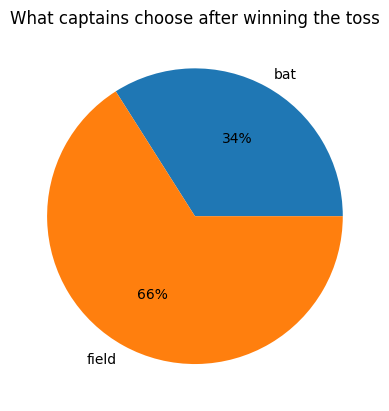

In [4]:
df = pd.read_sql("""
    SELECT toss_decision, COUNT(*) AS matches
    FROM matches GROUP BY toss_decision
""", con, index_col="toss_decision")
df.plot(kind="pie", y="matches", autopct="%.0f%%", legend=False, ylabel="",
        title="What captains choose after winning the toss")
plt.show()

## 4. Pace against spin (E) — bar
Spin concedes fewer runs per over than pace.

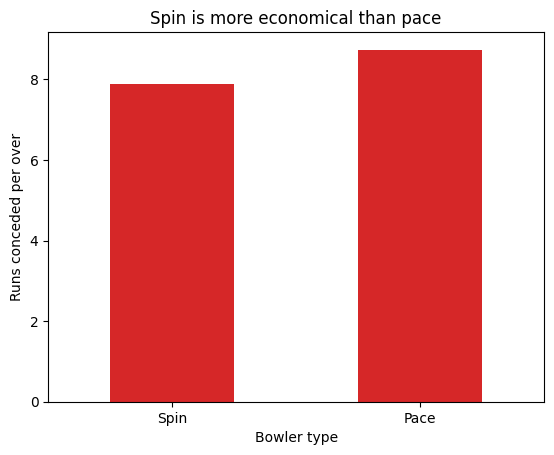

In [5]:
df = pd.read_sql("""
    SELECT CASE WHEN LOWER(bowler_type) LIKE '%break%' OR LOWER(bowler_type) LIKE '%orthodox%'
                  OR LOWER(bowler_type) LIKE '%wrist spin%' OR LOWER(bowler_type) LIKE '%googly%'
                THEN 'Spin' ELSE 'Pace' END AS bowler_kind,
           SUM(total_runs)*6.0 / SUM(CASE WHEN is_wide_ball=0 AND is_no_ball=0 THEN 1 ELSE 0 END) AS economy
    FROM deliveries WHERE is_super_over=0 AND TRIM(bowler_type)<>''
    GROUP BY bowler_kind ORDER BY bowler_kind DESC
""", con, index_col="bowler_kind")
df.plot(kind="bar", rot=0, legend=False, color=["#d62728","#1f77b4"],
        title="Spin is more economical than pace",
        xlabel="Bowler type", ylabel="Runs conceded per over")
plt.show()

## 5. First-innings scores by season (L) — line
Averages have risen from about 161 in 2008 to about 189 in recent seasons.

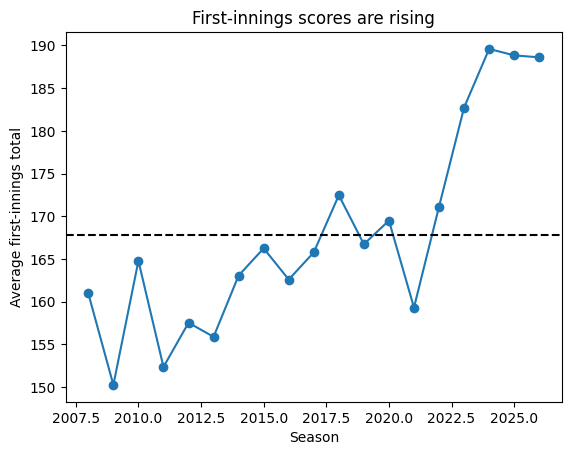

In [6]:
df = pd.read_sql("""
    SELECT season_id, AVG(total) AS avg_first_innings FROM (
        SELECT season_id, match_id, SUM(total_runs) AS total
        FROM deliveries WHERE is_super_over=0 AND innings=1
        GROUP BY season_id, match_id)
    GROUP BY season_id ORDER BY season_id
""", con, index_col="season_id")
df.plot(kind="line", marker="o", legend=False, color="#1f77b4",
        title="First-innings scores are rising",
        xlabel="Season", ylabel="Average first-innings total")
plt.axhline(df.avg_first_innings.mean(), ls="--", c="k"); plt.show()

## 6. Left-hand against right-hand batters (A8) — bar
Their strike rates are almost the same — the gap is tiny.

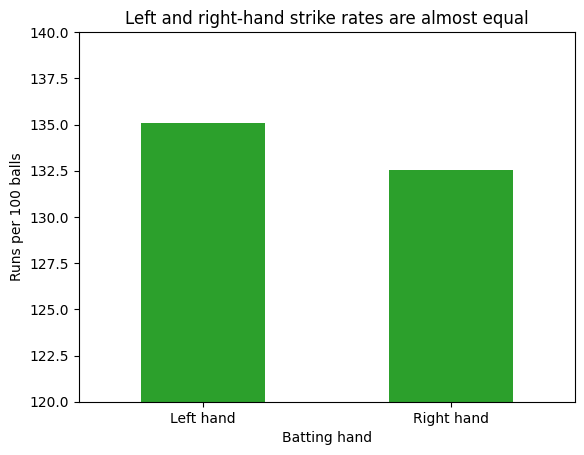

In [7]:
df = pd.read_sql("""
    SELECT CASE WHEN LOWER(batsman_type) LIKE '%left%' THEN 'Left hand' ELSE 'Right hand' END AS batting_hand,
           SUM(batter_runs)*100.0 / SUM(CASE WHEN is_wide_ball=0 AND is_no_ball=0 THEN 1 ELSE 0 END) AS strike_rate
    FROM deliveries WHERE is_super_over=0 AND TRIM(batsman_type)<>''
    GROUP BY batting_hand
""", con, index_col="batting_hand")
df.plot(kind="bar", rot=0, legend=False, ylim=(120,140), color=["#2ca02c","#1f77b4"],
        title="Left and right-hand strike rates are almost equal",
        xlabel="Batting hand", ylabel="Runs per 100 balls")
plt.show()

## 7. How wickets fall (K) — horizontal bar
Two out of every three wickets are catches.

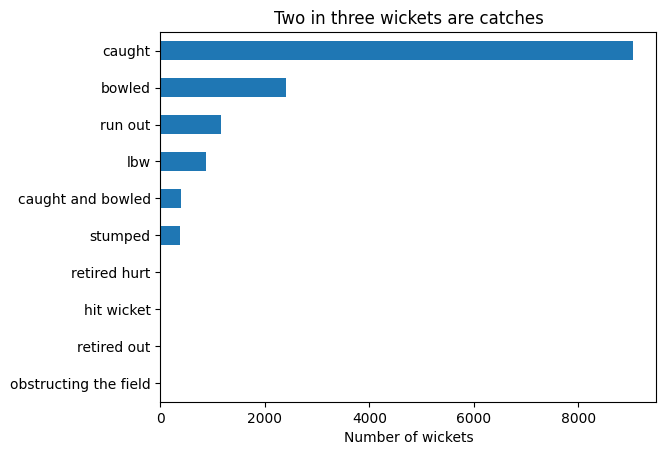

In [8]:
df = pd.read_sql("""
    SELECT wicket_kind, COUNT(*) AS wickets
    FROM deliveries WHERE is_super_over=0 AND is_wicket=1 AND TRIM(COALESCE(wicket_kind,''))<>''
    GROUP BY wicket_kind ORDER BY wickets
""", con, index_col="wicket_kind")
df.plot(kind="barh", legend=False, color="#1f77b4",
        title="Two in three wickets are catches",
        xlabel="Number of wickets", ylabel="")
plt.show()

## 8. Top 10 run scorers — horizontal bar
The leading run-getters across all seasons.

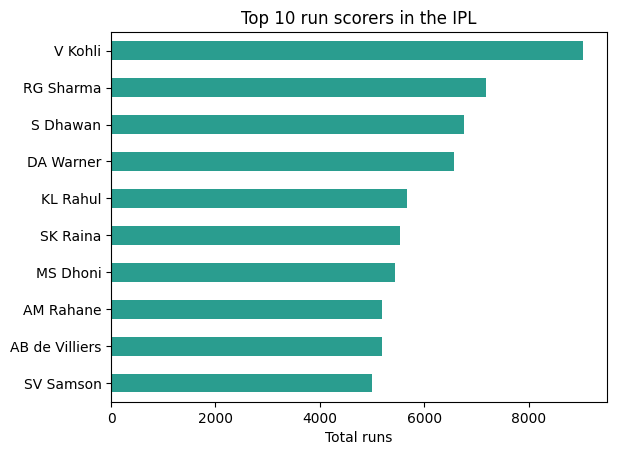

In [9]:
df = pd.read_sql("""
    SELECT * FROM (
        SELECT batter, SUM(batter_runs) AS runs
        FROM deliveries GROUP BY batter ORDER BY runs DESC LIMIT 10)
    ORDER BY runs
""", con, index_col="batter")
df.plot(kind="barh", legend=False, color="#2a9d8f",
        title="Top 10 run scorers in the IPL",
        xlabel="Total runs", ylabel="")
plt.show()

## 9. Top 10 wicket takers — horizontal bar
Run-outs are left out, because the bowler is not credited with them.

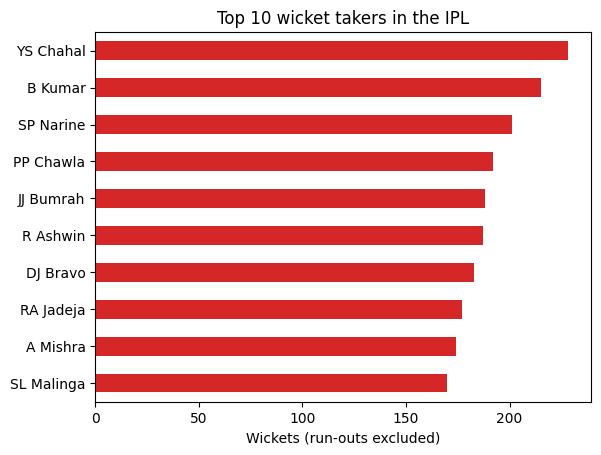

In [10]:
df = pd.read_sql("""
    SELECT * FROM (
        SELECT bowler, COUNT(*) AS wickets
        FROM deliveries
        WHERE is_wicket=1 AND wicket_kind NOT IN ('run out','retired hurt','retired out','obstructing the field')
        GROUP BY bowler ORDER BY wickets DESC LIMIT 10)
    ORDER BY wickets
""", con, index_col="bowler")
df.plot(kind="barh", legend=False, color="#d62728",
        title="Top 10 wicket takers in the IPL",
        xlabel="Wickets (run-outs excluded)", ylabel="")
plt.show()

## 10. Scoring over by over (1-20) — line
Runs per over dip in the middle overs and climb steeply at the death.

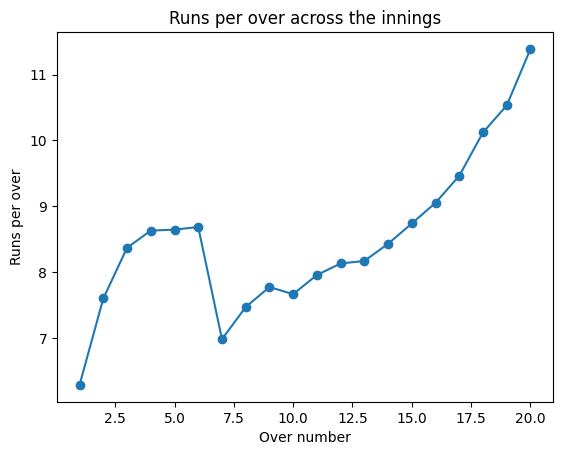

In [11]:
df = pd.read_sql("""
    SELECT over_number+1 AS over_no,
           SUM(total_runs)*6.0 / SUM(CASE WHEN is_wide_ball=0 AND is_no_ball=0 THEN 1 ELSE 0 END) AS runs_per_over
    FROM deliveries WHERE is_super_over=0
    GROUP BY over_number ORDER BY over_number
""", con, index_col="over_no")
df.plot(kind="line", marker="o", legend=False, color="#1f77b4",
        title="Runs per over across the innings",
        xlabel="Over number", ylabel="Runs per over")
plt.show()

## 11. Where the runs come from — pie
Boundaries (fours and sixes) make up a large share of all batting runs.

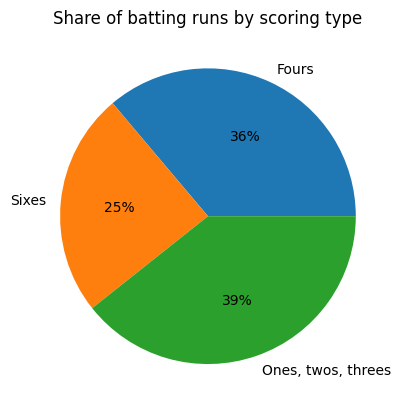

In [12]:
df = pd.read_sql("""
    SELECT 'Fours' AS run_type, SUM(CASE WHEN batter_runs=4 THEN 4 ELSE 0 END) AS runs FROM deliveries WHERE is_super_over=0
    UNION ALL SELECT 'Sixes', SUM(CASE WHEN batter_runs=6 THEN 6 ELSE 0 END) FROM deliveries WHERE is_super_over=0
    UNION ALL SELECT 'Ones, twos, threes', SUM(CASE WHEN batter_runs NOT IN (4,6) THEN batter_runs ELSE 0 END) FROM deliveries WHERE is_super_over=0
""", con, index_col="run_type")
df.plot(kind="pie", y="runs", autopct="%.0f%%", legend=False, ylabel="",
        title="Share of batting runs by scoring type")
plt.show()

## 12. Venue names before and after cleaning (I1) — bar
The same ground is written several ways, so the raw column over-counts venues.

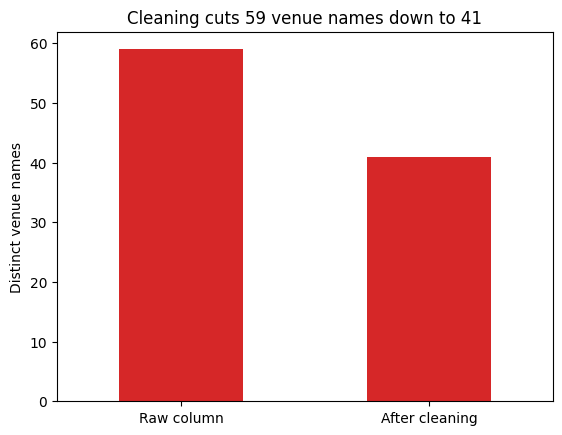

In [13]:
df = pd.read_sql("""
    SELECT 'Raw column' AS stage, COUNT(DISTINCT venue) AS venue_count FROM matches
    UNION ALL
    SELECT 'After cleaning',
           COUNT(DISTINCT CASE WHEN INSTR(venue, ',') > 0                         -- name has a city after a comma
                               THEN TRIM(REPLACE(SUBSTR(venue, 1, INSTR(venue, ',') - 1), '.', ' '))
                               ELSE TRIM(REPLACE(venue, '.', ' ')) END)           -- name has no comma
    FROM matches
""", con, index_col="stage")
df.plot(kind="bar", rot=0, legend=False, color=["#d62728","#2ca02c"],
        title="Cleaning cuts 59 venue names down to 41",
        xlabel="", ylabel="Distinct venue names")
plt.show()

In [14]:
con.close()